# Challenge 3: evaluación final e inferencia

El modelo ya fue seleccionado. Ahora debes abrir el conjunto de test una sola vez, comunicar su desempeño y comprobar que el pipeline puede reutilizarse con datos nuevos.

**Entradas:** `test.csv`, `data_contract.json` y `champion_model.joblib`  
**Salidas:** `test_metrics.json`, `batch_predictions.csv`

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga del modelo y del conjunto de prueba

In [3]:
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
training_metadata = json.loads((ARTIFACTS_DIR / "training_metadata.json").read_text(encoding="utf-8"))
model = joblib.load(ARTIFACTS_DIR / "champion_model.joblib")

test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")
X_test = test_df[contract["features"]]
y_test = test_df[contract["target"]]

print("Modelo:", training_metadata["champion"])
print("Test:", X_test.shape)

Modelo: logistic_regression
Test: (36, 13)


## 2. Evaluación final

Accuracy CV  : 0.9791
Accuracy test: 0.9722
F1 macro test: 0.9710



              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      0.933     1.000     0.966        14
     class_2      1.000     0.900     0.947        10

    accuracy                          0.972        36
   macro avg      0.978     0.967     0.971        36
weighted avg      0.974     0.972     0.972        36



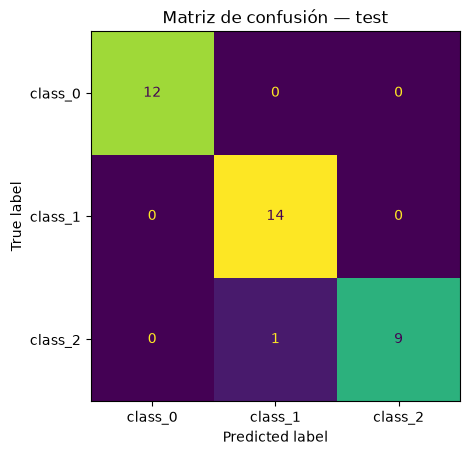

In [4]:
class_names = contract["target_names"]

y_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy CV  : {training_metadata['cv_score']:.4f}")
print(f"Accuracy test: {test_accuracy:.4f}")
print(f"F1 macro test: {test_f1_macro:.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=class_names, colorbar=False
)
plt.title("Matriz de confusión — test")
plt.show()

**Análisis:**

> ¿El desempeño es coherente con validación cruzada? ¿Qué clases se confunden? ¿Hay evidencia de sobreajuste?

- **Coherencia con CV:** sí. El accuracy en test es **0.972** (35 de 36 aciertos), frente a **0.979 ± 0.028** en validación cruzada; la diferencia (≈ 0.7 puntos) está muy dentro de la variabilidad entre folds. El F1 macro es **0.971**, así que el buen resultado no se debe a favorecer a la clase mayoritaria.
- **Confusiones:** hay **un único error**: un vino de la **clase 2 fue clasificado como clase 1**. Por eso el recall de la clase 2 baja a 0.90 y la precisión de la clase 1 a 0.933. La clase 0 se clasifica perfectamente. Esto es coherente con el EDA: las clases 1 y 2 se solapan más en algunas variables (por ejemplo, la prolina), mientras que la clase 0 se separa con claridad por su prolina alta.
- **Sobreajuste:** no hay evidencia relevante. Aunque el accuracy de entrenamiento es 1.0, el desempeño se mantiene tanto en CV como en un test que no se usó durante la selección. Con solo 36 ejemplos de test, cada error equivale a ≈ 2.8 puntos de accuracy, así que el intervalo de confianza real es amplio.

## 3. Función de inferencia

In [5]:
feature_columns = contract["features"]
class_names = contract["target_names"]

def predict(records: pd.DataFrame) -> pd.DataFrame:
    """Valida el esquema y devuelve las predicciones del pipeline."""
    missing = sorted(set(feature_columns) - set(records.columns))
    if missing:
        raise ValueError(f"Faltan variables requeridas: {missing}")

    extra = sorted(set(records.columns) - set(feature_columns))
    if extra:
        print(f"Advertencia: se ignorarán columnas adicionales: {extra}")

    # Mismo orden de columnas que en entrenamiento
    X = records[feature_columns]

    labels = model.predict(X)
    probabilities = model.predict_proba(X)

    result = pd.DataFrame({
        "prediction": labels,
        "predicted_class": [class_names[label] for label in labels],
    }, index=records.index)
    for k, name in enumerate(class_names):
        result[f"probability_{name}"] = probabilities[:, k]
    return result


# Prueba de la validación del esquema
try:
    predict(X_test.drop(columns=["alcohol"]).head(1))
except ValueError as error:
    print("Validación OK ->", error)

Validación OK -> Faltan variables requeridas: ['alcohol']


## 4. Predicción por lotes

In [6]:
# Simulación de datos nuevos. En producción no provendrían del test set.
new_records = X_test.iloc[:5].copy()

# Columnas desordenadas: predict debe reordenarlas
new_records = new_records[new_records.columns[::-1]]

batch_predictions = predict(new_records)
batch_predictions.to_csv(REPORTS_DIR / "batch_predictions.csv", index=False)
batch_predictions.round(3)

,prediction,predicted_class,probability_class_0,probability_class_1,probability_class_2
0,0,class_0,1.000,0.000,0.000
1,1,class_1,0.007,0.540,0.453
2,0,class_0,0.992,0.008,0.000
3,1,class_1,0.290,0.707,0.003
4,1,class_1,0.033,0.962,0.005


## 5. Reporte final

In [7]:
test_metrics = {
    "model": training_metadata["champion"],
    "best_params": training_metadata["best_params"],
    "cv_accuracy": float(training_metadata["cv_score"]),
    "test_accuracy": float(test_accuracy),
    "test_f1_macro": float(test_f1_macro),
    "n_test": int(len(y_test)),
}
(REPORTS_DIR / "test_metrics.json").write_text(
    json.dumps(test_metrics, indent=2), encoding="utf-8"
)
print(json.dumps(test_metrics, indent=2))
print("Reporte final guardado. El test no debe reutilizarse para ajustar el modelo.")

{
  "model": "logistic_regression",
  "best_params": {
    "classifier__C": 1
  },
  "cv_accuracy": 0.9790640394088669,
  "test_accuracy": 0.9722222222222222,
  "test_f1_macro": 0.9709618874773139,
  "n_test": 36
}
Reporte final guardado. El test no debe reutilizarse para ajustar el modelo.


In [8]:
assert (REPORTS_DIR / "test_metrics.json").exists()
assert (REPORTS_DIR / "batch_predictions.csv").exists()
print("Challenge 3 completado.")

Challenge 3 completado.


## Resumen ejecutivo

| Elemento | Resultado |
|---|---|
| Modelo campeón | Regresión Logística (`C = 1`) con imputación por mediana + `StandardScaler` |
| Accuracy CV | 0.979 ± 0.028 (5 folds estratificados) |
| Accuracy test | 0.972 (35/36) |
| F1 macro test | 0.971 |
| Clases más confundidas | Clase 2 → clase 1 (un único error) |
| Principal limitación | Dataset muy pequeño (178 vinos, 36 en test): cada error mueve el accuracy ≈ 3 puntos y las métricas tienen alta incertidumbre. Además, los vinos provienen de una sola región, así que no está garantizado que el modelo generalice a otras regiones o a cambios en la medición. |

## Checklist

- [x] Evalué únicamente el modelo campeón.
- [x] No reajusté hiperparámetros después de observar test.
- [x] Implementé validación básica del esquema de entrada.
- [x] Generé predicciones por lotes.
- [x] Guardé las métricas finales.